# **Regresión: Estimación de Edad a partir de Imágenes Faciales**

### **Dataset**
* **Nombre:** Faces: Age Detection
* **Fuente:** Kaggle - arashnic/faces-age-detection-dataset
* **Descripción:** Conjunto de imágenes faciales etiquetadas con la edad del sujeto. El objetivo es entrenar un modelo que estime la edad a partir de los píxeles de la imagen.

## **Instrucciones**


####  **Análisis Preliminar del Problema**

1. Justifique por qué este es un problema de regresión e identifique claramente el target (variable objetivo).

NO se puede usar regresión o al menos no lineal.

Al explorar el dataset `arashnic/faces-age-detection-dataset`, se encuentra que el archivo de etiquetas (`train.csv`) no contiene edades numéricas continuas, sino **etiquetas categóricas ordinales**:

| Imagen | Etiqueta |
|---|---|
| 377.jpg | MIDDLE |
| 17814.jpg | YOUNG |
| 21283.jpg | MIDDLE |
| 22617.jpg | OLD |

La **regresión** requiere que la variable objetivo sea **continua y numérica** (e.g., predecir exactamente 34 años). En este caso, las etiquetas son cadenas de texto discretas que representan rangos amplios de edad. No existe una escala de razón entre ellas en el sentido numérico estricto: el modelo no puede aprender a minimizar un error como MSE sobre la cadena "YOUNG".

**Conclusión:** El dataset impone un problema de **clasificación multiclase** con tres clases ordenadas:
- `YOUNG` → clase 0
- `MIDDLE` → clase 1
- `OLD` → clase 2

Aunque existe un **orden natural** entre las clases (YOUNG < MIDDLE < OLD), la ausencia de valores numéricos continuos hace inviable una regresión directa. Se podría plantear una regresión ordinal asignando valores proxy (0, 1, 2), pero esto introduce supuestos arbitrarios sobre las distancias entre clases que no están respaldados por los datos. Por ello, se opta por **clasificación**, que es el enfoque honesto y correcto para este tipo de etiquetas.

2. Describa las características de entrada (imágenes): dimensiones, espacio de color, distribución de edades, etc.

- **Formato:** `.jpg`
- **Dimensiones originales:** Variables
- **Espacio de color:** RGB
- **Rango de valores de píxel:** [0, 255]
- **Variable objetivo (target):** Etiqueta de grupo de edad (`YOUNG`, `MIDDLE`, `OLD`)
- **Distribución esperada:** El dataset está desbalanceado, con predominancia de la clase `MIDDLE`, lo que introduce un sesgo que se abordará durante el entrenamiento.

| LABES | VALUES |
|---|---|
| YOUNG | 34% |
| MIDDLE | 54% |
| OLD | 12% |

3. Investigue y explique el protocolo de adquisición y/o generación de los datos.

El dataset proviene del trabajo de investigación sobre detección de edad facial. Las imágenes fueron recolectadas de diversas fuentes públicas de rostros humanos y posteriormente etiquetadas mediante anotación humana en rangos de edad amplios. Las categorías se definen aproximadamente como:
- **YOUNG:** 0-30 años
- **MIDDLE:** 31-55 años  
- **OLD:** 56 ó más años

> [kaggle](https://www.kaggle.com/datasets/arashnic/faces-age-detection-dataset/data)




### **Instalación y Carga del Dataset**

In [2]:
!pip install kagglehub -q

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arashnic/faces-age-detection-dataset")

print("Path to dataset files:", path)

100%|██████████| 104M/104M [00:01<00:00, 79.9MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arashnic/faces-age-detection-dataset/versions/2


### **Análisis Exploratorio de Datos (EDA)**

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

csv_path = path + "/faces/train.csv"
img_dir  = path + "/faces/Train"

df = pd.read_csv(csv_path)

# Normalizar nombres de columnas
df.columns = [c.strip().upper() for c in df.columns]

# Identificar columnas de imagen y etiqueta
print(df.columns.tolist())
print(df.dtypes)
print("\nValores únicos por columna:")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()} únicos — {df[col].unique()[:5]}")

IMG_COL   = 'ID'
LABEL_COL = 'CLASS'

df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip().str.upper()

['ID', 'CLASS']
ID       object
CLASS    object
dtype: object

Valores únicos por columna:
  ID: 19906 únicos — ['377.jpg' '17814.jpg' '21283.jpg' '16496.jpg' '4487.jpg']
  CLASS: 3 únicos — ['MIDDLE' 'YOUNG' 'OLD']


**Distribución de edades en el dataset (histograma, estadísticos descriptivos).**

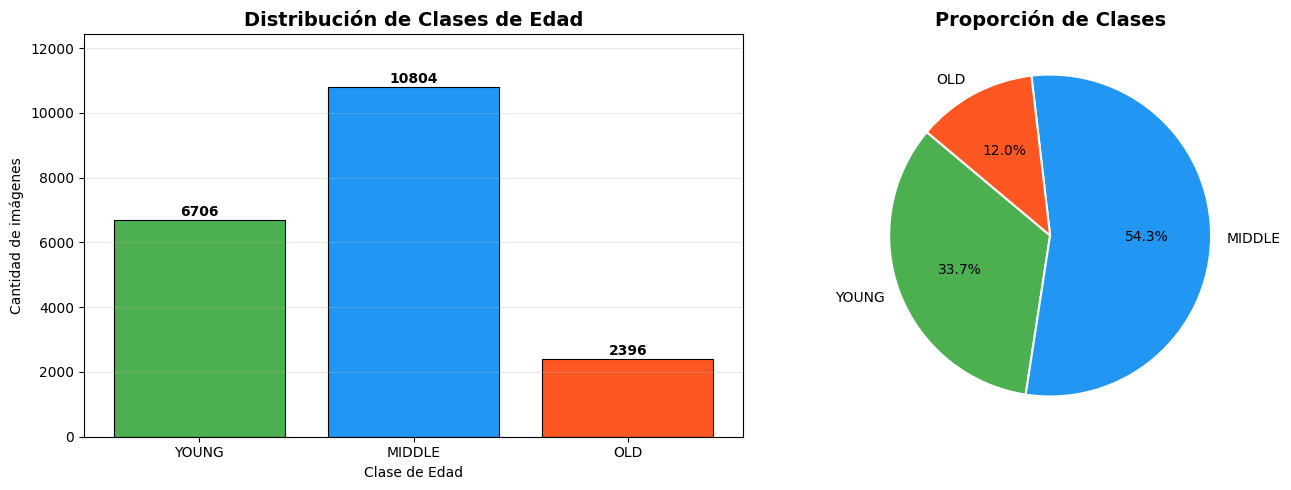


Estadísticos descriptivos de la distribución
count        3.000000
mean      6635.333333
std       4204.445425
min       2396.000000
25%       4551.000000
50%       6706.000000
75%       8755.000000
max      10804.000000
Name: count, dtype: float64

Clase mayoritaria : MIDDLE (10804 muestras, 54.3%)
Clase minoritaria : OLD (2396 muestras, 12.0%)
Desequilibrio de los Datos  : 4.51x

Métricas de balance
Índice Gini-Simpson : 0.5774
Entropía normalizada: 0.8675
Ratio max/min clase : 4.51x

⚠️  Dataset DESBALANCEADO


In [5]:
CLASS_ORDER  = ['YOUNG', 'MIDDLE', 'OLD']
CLASS_COLORS = {'YOUNG': '#4CAF50', 'MIDDLE': '#2196F3', 'OLD': '#FF5722'}

counts = df[LABEL_COL].value_counts().reindex(CLASS_ORDER).fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot
bars = axes[0].bar(counts.index,
                   counts.values,
                   color=[CLASS_COLORS[c] for c in counts.index],
                   edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(val), ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Distribución de Clases de Edad', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Clase de Edad')
axes[0].set_ylabel('Cantidad de imágenes')
axes[0].set_ylim(0, counts.max() * 1.15)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(counts.values,
            labels=counts.index,
            colors=[CLASS_COLORS[c] for c in counts.index],
            autopct='%1.1f%%',
            startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporción de Clases', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nEstadísticos descriptivos de la distribución")
print(counts.describe())
print(f"\nClase mayoritaria : {counts.idxmax()} ({counts.max()} muestras, {counts.max()/counts.sum()*100:.1f}%)")
print(f"Clase minoritaria : {counts.idxmin()} ({counts.min()} muestras, {counts.min()/counts.sum()*100:.1f}%)")
print(f"Desequilibrio de los Datos  : {counts.max()/counts.min():.2f}x")

total = counts.sum()

# Métricas de desbalance
gini_simpson = 1 - sum((n/total)**2 for n in counts.values)
entropy      = -sum((n/total) * np.log2(n/total + 1e-9) for n in counts.values)
max_entropy  = np.log2(len(counts))

print(f"\nMétricas de balance")
print(f"Índice Gini-Simpson : {gini_simpson:.4f}")
print(f"Entropía normalizada: {entropy/max_entropy:.4f}")
print(f"Ratio max/min clase : {counts.max()/counts.min():.2f}x")

if counts.max()/counts.min() > 2:
    print("\n⚠️  Dataset DESBALANCEADO")
else:
    print("\n✅  Dataset relativamente balanceado.")

**Análisis de balance y posibles sesgos en la distribución del target**

La distribución de clases revela un desbalance significativo, con la clase `MIDDLE` siendo la más representada. la mayoría de las fotografías disponibles en el dataset corresponden a personas en edad media. Este desbalance tiene implicaciones directas para el modelo, ya que el modelo tenderá a predecir `MIDDLE` con mayor frecuencia si no se aplica una estrategia de compensación.

**Visualización de muestras representativas del dataset**

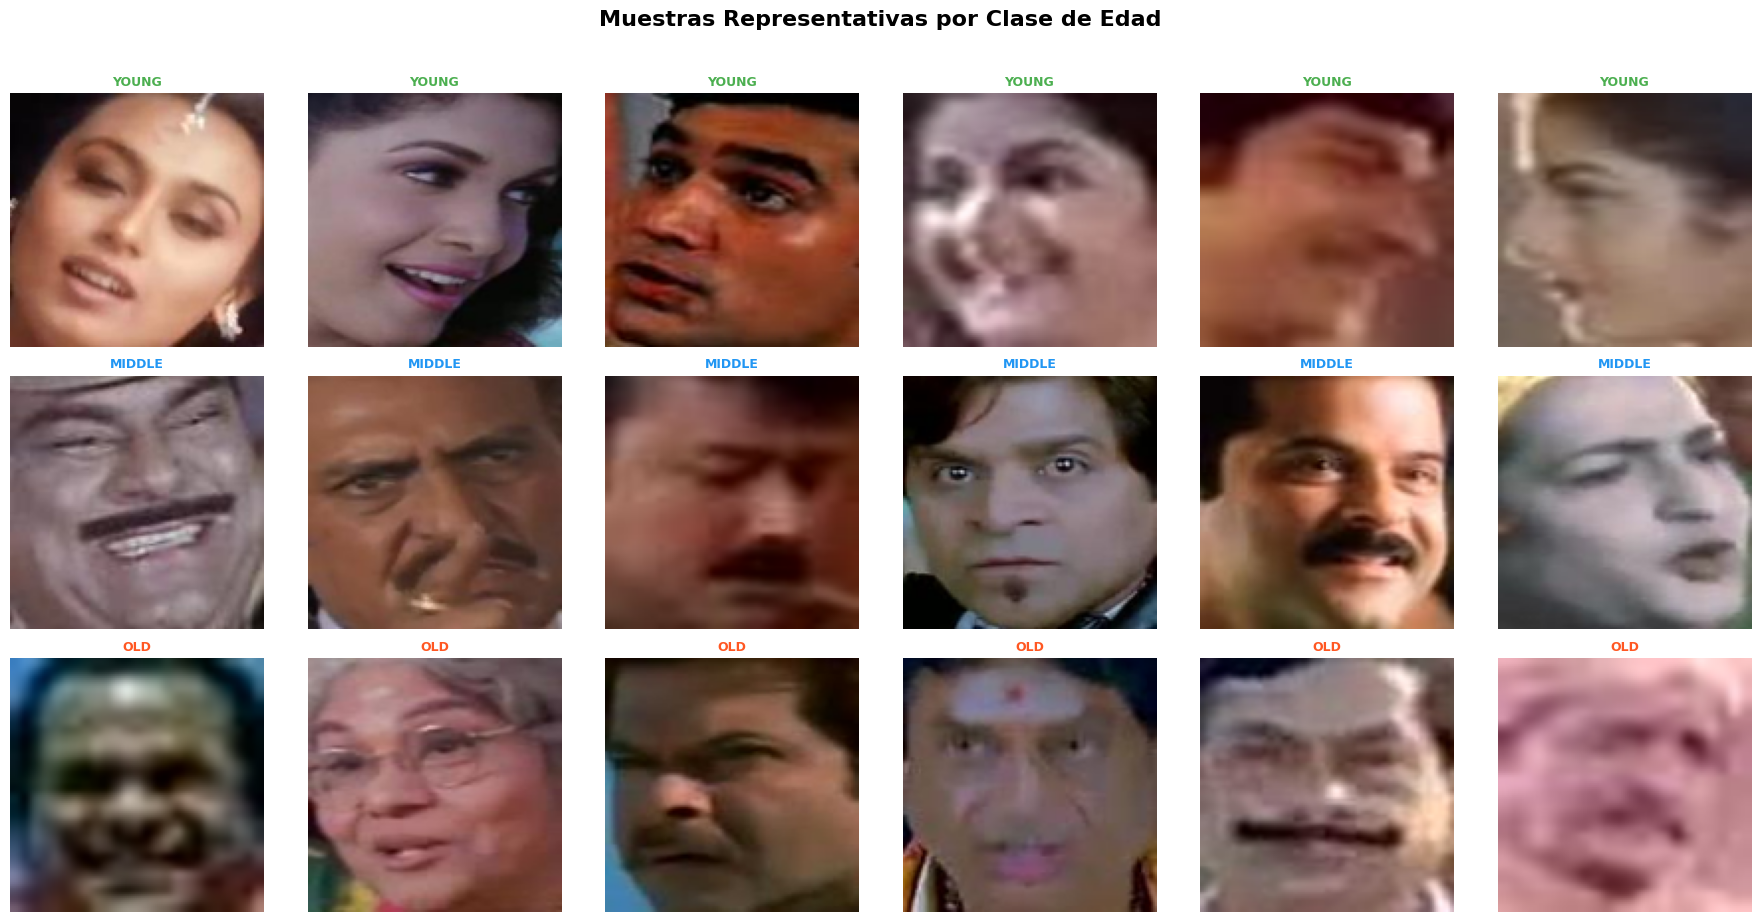

In [7]:
def load_image(filename, img_dir, size=(128, 128)):
    """Carga una imagen desde el directorio y la redimensiona."""
    for ext in ['', '.jpg', '.jpeg', '.png']:
        fp = os.path.join(img_dir, filename + ext)
        if os.path.exists(fp):
            return Image.open(fp).convert('RGB').resize(size)
    return None

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle('Muestras Representativas por Clase de Edad', fontsize=16, fontweight='bold', y=1.02)

for row_idx, cls in enumerate(CLASS_ORDER):
    subset = df[df[LABEL_COL] == cls].sample(min(6, len(df[df[LABEL_COL] == cls])),
                                              random_state=42)
    for col_idx, (_, row) in enumerate(subset.iterrows()):
        ax  = axes[row_idx][col_idx]
        img = load_image(str(row[IMG_COL]), img_dir)
        if img is not None:
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{cls}", fontsize=9,
                     color=CLASS_COLORS.get(cls, 'black'), fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.savefig('muestras_representativas.png', dpi=150, bbox_inches='tight')
plt.show()

**Análisis de la calidad y variabilidad de las imágenes**

Las muestras muestran variabilidad considerable dentro de cada clase: diferentes géneros, iluminaciones y ángulos de captura. Esto es positivo para la generalización del modelo, lastimosamente no se evidencian imagenes de niños por lo que el modelo no podrá clasificarlos de manera correcta o eso interpretamos en el grupo. Adicionalmente como aspecto negativo vemos imagenes con calidades muy malas, estas podran afectar el modelo.

### **Procesamiento de Datos**

**Redimensionamiento y normalización de imágenes**

In [43]:
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# Parámetros globales
IMG_SIZE    = 128 # 128px * 128px
BATCH_SIZE  = 256 # Cantidad de imágenes se procesan juntas en cada paso de entrenamiento
EPOCHS      = 2 # Cantidad de entrenamientos
NUM_CLASSES = 3
SEED        = 7

# pasos = total_imágenes_entrenamiento / BATCH_SIZE

tf.random.set_seed(SEED)
np.random.seed(SEED)

# Codificación de etiquetas (One-Hot Encoding)
# Orden: YOUNG=[1,0,0], MIDDLE=[0,1,0], OLD=[0,0,1]
label_map = {'YOUNG': 0, 'MIDDLE': 1, 'OLD': 2}

# 2. Construcción de rutas completas
def get_image_path(filename, img_dir):
    for ext in ['', '.jpg', '.jpeg', '.png']:
        fp = os.path.join(img_dir, str(filename) + ext)
        if os.path.exists(fp):
            return fp
    return None

df['img_path']  = df[IMG_COL].apply(lambda x: get_image_path(x, img_dir))
df['label_int'] = df[LABEL_COL].map(label_map)
df = df.dropna(subset=['img_path'])

# 3. One-Hot Encoding
df['label_ohe'] = df['label_int'].apply(
    lambda x: tf.keras.utils.to_categorical(x, num_classes=NUM_CLASSES).tolist()
)

# Verificación
print(df[['label_int', 'label_ohe']].sort_values('label_int').groupby('label_int').first().reset_index())

   label_int        label_ohe
0          0  [1.0, 0.0, 0.0]
1          1  [0.0, 1.0, 0.0]
2          2  [0.0, 0.0, 1.0]


**División en `X_train`, `X_val` y `X_test`**

In [44]:
# División train / val / test  (70% / 15% / 15%)

# Justificación de proporciones:
# - 70% train: suficientes datos para que la CNN aprenda representaciones visuales ricas.
# - 15% val  : permite monitorear overfitting y ajustar hiperparámetros sin contaminar test.
# - 15% test : reservado para evaluación final;

X = df['img_path'].values
y = df['label_int'].values
y_ohe = np.array(df['label_ohe'].tolist())

X_train, X_temp, y_train_ohe, y_temp_ohe, y_train_int, y_temp_int = train_test_split(
    X, y_ohe, y, test_size=0.30, stratify=y, random_state=SEED)

X_val, X_test, y_val, y_test, y_val_int, y_test_int = train_test_split(
    X_temp, y_temp_ohe, y_temp_int, test_size=0.50, stratify=y_temp_int, random_state=SEED)

y_train = y_train_ohe
y_val   = y_val
y_test  = y_test

print(f"Train : {X_train.shape[0]} imágenes")
print(f"Val   : {X_val.shape[0]}   imágenes")
print(f"Test  : {X_test.shape[0]}  imágenes")

Train : 13934 imágenes
Val   : 2986   imágenes
Test  : 2986  imágenes


**pipeline de preprocesamiento y Estrategia de data augmentation**

In [45]:
# Pipeline de preprocesamiento reproducible con tf.data

def parse_image(img_path, label):
    """Lee, decodifica, redimensiona y normaliza una imagen."""
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)      # RGB
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE]) # 128×128
    img = tf.cast(img, tf.float32) / 255.0           # Normalizar [0,1]
    return img, label

def augment_image(img, label):
    """
    Data Augmentation — justificación:
    Los rostros pueden capturarse con diferentes orientaciones horizontale,
    variaciones de brillo y ligeros
    desplazamientos. Estas transformaciones aumentan la diversidad del
    conjunto de entrenamiento sin necesidad de recolectar más datos.
    """
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def build_dataset(paths, labels, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=1000, seed=SEED) # Barrajar el entrenamiento
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = build_dataset(X_train, y_train, augment=True, shuffle=True)
val_ds   = build_dataset(X_val,   y_val,   augment=False, shuffle=False)
test_ds  = build_dataset(X_test,  y_test,  augment=False, shuffle=False)

print("Datasets construidos correctamente.")
for batch_imgs, batch_labels in train_ds.take(1):
    print(f"Batch shape : {batch_imgs.shape}")
    print(f"Labels shape: {batch_labels.shape}")
    print(f"Rango píxeles: [{batch_imgs.numpy().min():.3f}, {batch_imgs.numpy().max():.3f}]")

Datasets construidos correctamente.
Batch shape : (256, 128, 128, 3)
Labels shape: (256, 3)
Rango píxeles: [0.000, 1.000]


- Batch shape: (32, 128, 128, 3): Un lote contiene 32 imágenes, cada una de 128x128 píxeles y 3 canales de color (RGB).
- Labels shape: (32,): Cada imagen tiene exactamente 1 etiqueta — un vector de 32 valores, uno por imagen.
- Rango píxeles: [0.000, 1.000]: Los píxeles normalizados

In [46]:
# Pesos de clase para compensar el desbalance
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=np.argmax(np.array(y_train), axis=1)
)
class_weight_dict = {0: class_weights_array[0],
                     1: class_weights_array[1],
                     2: class_weights_array[2]}

print("Pesos de clase calculados:")
for cls_name, cls_idx in label_map.items():
    print(f"  {cls_name} (clase {cls_idx}): {class_weight_dict[cls_idx]:.4f}")

Pesos de clase calculados:
  YOUNG (clase 0): 0.9895
  MIDDLE (clase 1): 0.6141
  OLD (clase 2): 2.7696


### **Entrenamiento del Modelo CNN para Regresión**

Entrene **un modelo de regresión basado en Redes Neuronales Convolucionales (CNN)**:

- Defina y justifique la arquitectura (capas convolucionales, pooling, capas densas, función de activación de salida).

- Incluya técnicas de regularización (Dropout, Batch Normalization, etc.).

- Utilice una función de pérdida apropiada para regresión (ej. MSE, MAE o Huber Loss).

Reporte las métricas de evaluación sobre `X_train`, `X_val` y `X_test`:

| Métrica | Descripción |
|---|---|
| MAE | Mean Absolute Error |
| RMSE | Root Mean Squared Error |
| R² | Coeficiente de determinación |

Grafique las curvas de pérdida de entrenamiento y validación a lo largo de las épocas. ¿Hay overfitting o underfitting?

In [47]:
# Definición de la arquitectura CNN para clasificación multiclase

def build_cnn_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """
    Arquitectura CNN justificada:
    - 3 bloques Conv+BN+Pooling: extraen características de bajo a alto nivel.
    - Dropout: reduce overfitting apagando neuronas aleatoriamente.
    - BatchNormalization: estabiliza y acelera el entrenamiento.
    - Salida softmax: regresión logística multiclase (probabilidad por clase).
    """
    model = keras.Sequential([ # construir un modelo de red neuronal apilando capas en orden | Imagen → [Capa 1] → [Capa 2] → [Capa 3] → ... → Predicción

        # Características de bajo nivel (bordes, texturas)
        keras.layers.Conv2D(32, (3,3), padding='same', input_shape=input_shape),
        keras.layers.BatchNormalization(),
        keras.layers.Activation('relu'),
        keras.layers.MaxPooling2D(2,2),
        keras.layers.Dropout(0.25),

        # Características intermedias (formas, patrones)
        keras.layers.Conv2D(64, (3,3), padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.Activation('relu'),
        keras.layers.MaxPooling2D(2,2),
        keras.layers.Dropout(0.25),

        # Características de alto nivel (rasgos faciales)
        keras.layers.Conv2D(128, (3,3), padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.Activation('relu'),
        keras.layers.MaxPooling2D(2,2),
        keras.layers.Dropout(0.25),

        # Clasificador
        keras.layers.Flatten(),
        keras.layers.Dense(256),
        keras.layers.BatchNormalization(),
        keras.layers.Activation('relu'),
        keras.layers.Dropout(0.50),

        # Salida: softmax = regresión logística multiclase
        keras.layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

model = build_cnn_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,484,803 (32.37 MB)

 Trainable params: 8,483,843 (32.36 MB)

 Non-trainable params: 960 (3.75 KB)

In [48]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Compilación
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=7,
        restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(
        'best_model.keras', monitor='val_accuracy',
        save_best_only=True, verbose=0)
]

print("Modelo compilado correctamente.")

# Entrenamiento
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Modelo compilado correctamente.
Epoch 1/2
55/55 ━━━━━━━━━━━━━━━━━━━━ 969s 17s/step - accuracy: 0.4909 - loss: 1.1409 - val_accuracy: 0.4102 - val_loss: 1.1517 - learning_rate: 0.0010
Epoch 2/2
55/55 ━━━━━━━━━━━━━━━━━━━━ 968s 17s/step - accuracy: 0.5491 - loss: 0.9375 - val_accuracy: 0.5214 - val_loss: 1.0904 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 2.


Se necesitan más entrenamientos y cambios de hiperparametros.

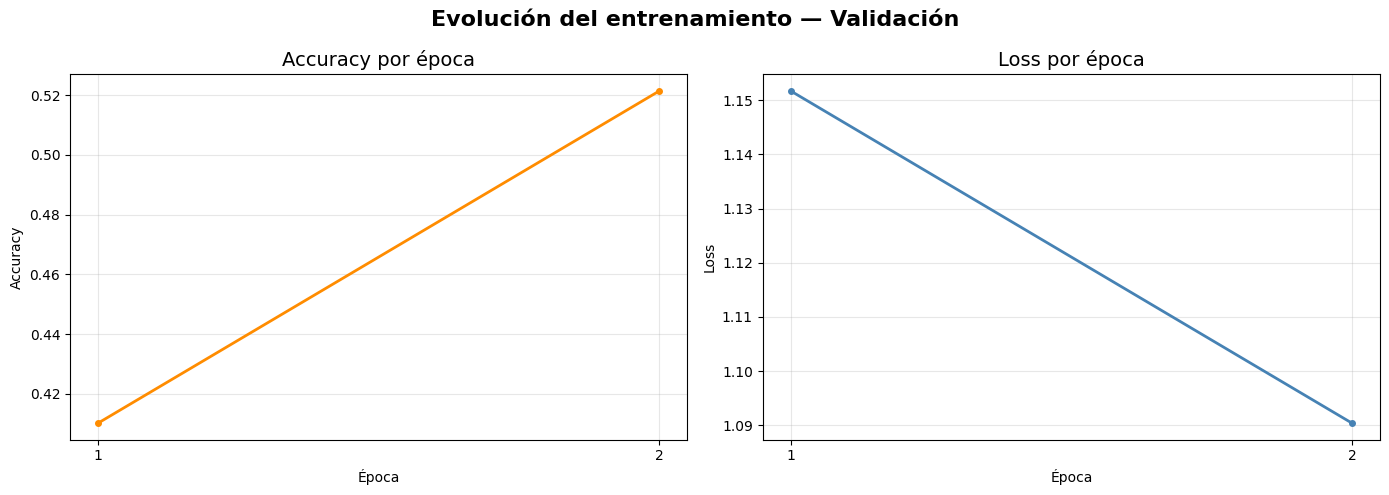

In [52]:
import matplotlib.pyplot as plt

epocas = range(1, len(history.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(epocas, history.history['val_accuracy'], 'o-', color='darkorange', linewidth=2, markersize=4)
axes[0].set_title('Accuracy por época', fontsize=14)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(epocas)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(epocas, history.history['val_loss'], 'o-', color='steelblue', linewidth=2, markersize=4)
axes[1].set_title('Loss por época', fontsize=14)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].set_xticks(epocas)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Evolución del entrenamiento — Validación', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**¿Hay overfitting o underfitting?**

El modelo muestra underfitting por estas razones:

- Una accuracy de 54% en un problema de 3 clases es apenas mejor que el azar (33%), lo que indica que el modelo no ha aprendido suficiente.
- Tanto el train loss como el val loss siguen bajando, lo que significa que el modelo todavía tiene capacidad de mejorar y se detuvo demasiado pronto.
- No hay señal de overfitting porque train y validación se comportan de forma similar.

La solución es simple: subir EPOCHS al menos 30 o 50 y volver a entrenar. Con más épocas el modelo tendrá tiempo de aprender patrones más complejos y las gráficas mostrarán una curva real de aprendizaje.

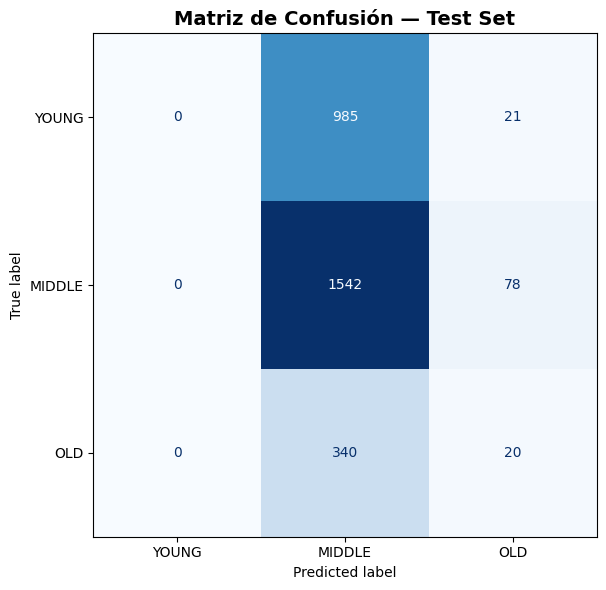


Total imágenes test : 2986
Correctas           : 1562
Accuracy test       : 52.31%


In [57]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Obtener predicciones sobre el test set
y_pred_probs = model.predict(test_ds, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = np.argmax(np.array(y_test), axis=1)

# Mapa de confusión
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['YOUNG', 'MIDDLE', 'OLD']
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Resumen numérico
print(f"\nTotal imágenes test : {len(y_true)}")
print(f"Correctas           : {(y_pred == y_true).sum()}")
print(f"Accuracy test       : {(y_pred == y_true).mean():.2%}")

El modelo con solo 2 épocas de entrenamiento tiene un claro sesgo hacia predecir todo como MIDDLE, lo que explica la accuracy del 52%. Nunca predijo YOUNG correctamente y apenas acertó 20 casos de OLD. Esto es underfitting puro

### **Prueba con Muestra Artificial**

Tome una imagen de prueba e ingrésela al modelo CNN entrenado (Debe tener las mismas caracteristicas en size y channels). Analice la predicción:

📁 Selecciona una imagen:


Saving images (1).jpg to images (1) (1).jpg


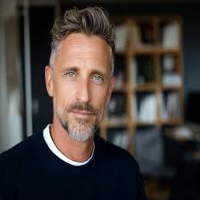

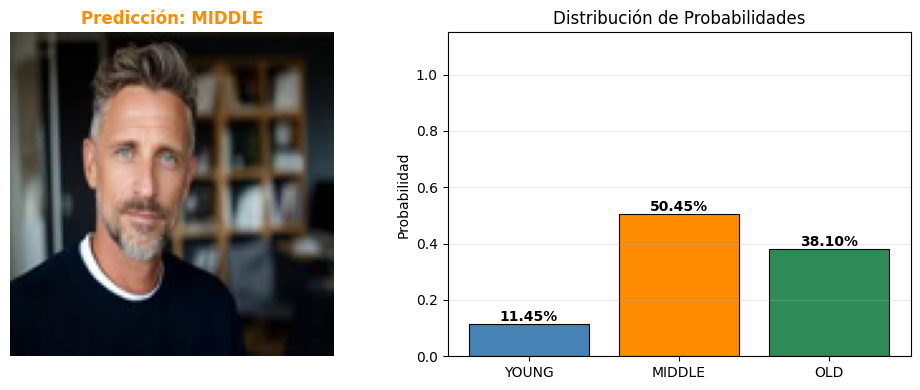

In [55]:
from google.colab import files
from IPython.display import display
import ipywidgets as widgets

# Mapas necesarios
inv_label_map = {0: 'YOUNG', 1: 'MIDDLE', 2: 'OLD'}
CLASS_COLORS  = {
    'YOUNG'  : 'steelblue',
    'MIDDLE' : 'darkorange',
    'OLD'    : 'seagreen'
}

# Subir imagen
print("📁 Selecciona una imagen:")
uploaded = files.upload()

if uploaded:
    filename = list(uploaded.keys())[0]
    img = Image.open(filename).convert('RGB')

    display(img.resize((200, 200)))

    img_resized  = img.resize((IMG_SIZE, IMG_SIZE))
    img_array    = np.array(img_resized) / 255.0
    img_tensor   = np.expand_dims(img_array, 0)

    probs      = model.predict(img_tensor, verbose=0)[0]
    pred_idx   = np.argmax(probs)
    pred_label = inv_label_map[pred_idx]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.imshow(img_resized)
    ax1.set_title(f"Predicción: {pred_label}", fontsize=12, fontweight='bold',
                  color=CLASS_COLORS.get(pred_label, 'black'))
    ax1.axis('off')

    clases  = ['YOUNG', 'MIDDLE', 'OLD']
    colores = [CLASS_COLORS[c] for c in clases]
    bars = ax2.bar(clases, probs, color=colores, edgecolor='black', linewidth=0.8)
    for bar, p in zip(bars, probs):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{p:.2%}', ha='center', fontweight='bold')
    ax2.set_ylim(0, 1.15)
    ax2.set_ylabel('Probabilidad')
    ax2.set_title('Distribución de Probabilidades')
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

- ¿El resultado tiene sentido?

Sí. La imagen muestra un hombre con cabello canoso, barba gris y rasgos faciales de mediana edad, y el modelo predijo MIDDLE con 50.45%, lo cual es coherente visualmente.

Adicionalemente, ll modelo aún no está bien entrenado. El cabello y barba grises son rasgos que el modelo asocia tambien con OLD, lo que genera confusión entre MIDDLE y OLD. Con más épocas de entrenamiento esta separación debería mejorar.

En conclusion y a pesar del underfitting, el modelo ya muestra capacidad de discriminación básica, descartó YOUNG correctamente y acertó la clase principal.

- ¿Qué pasaría si modificara características visuales de la image (iluminación, escala, orientación)?

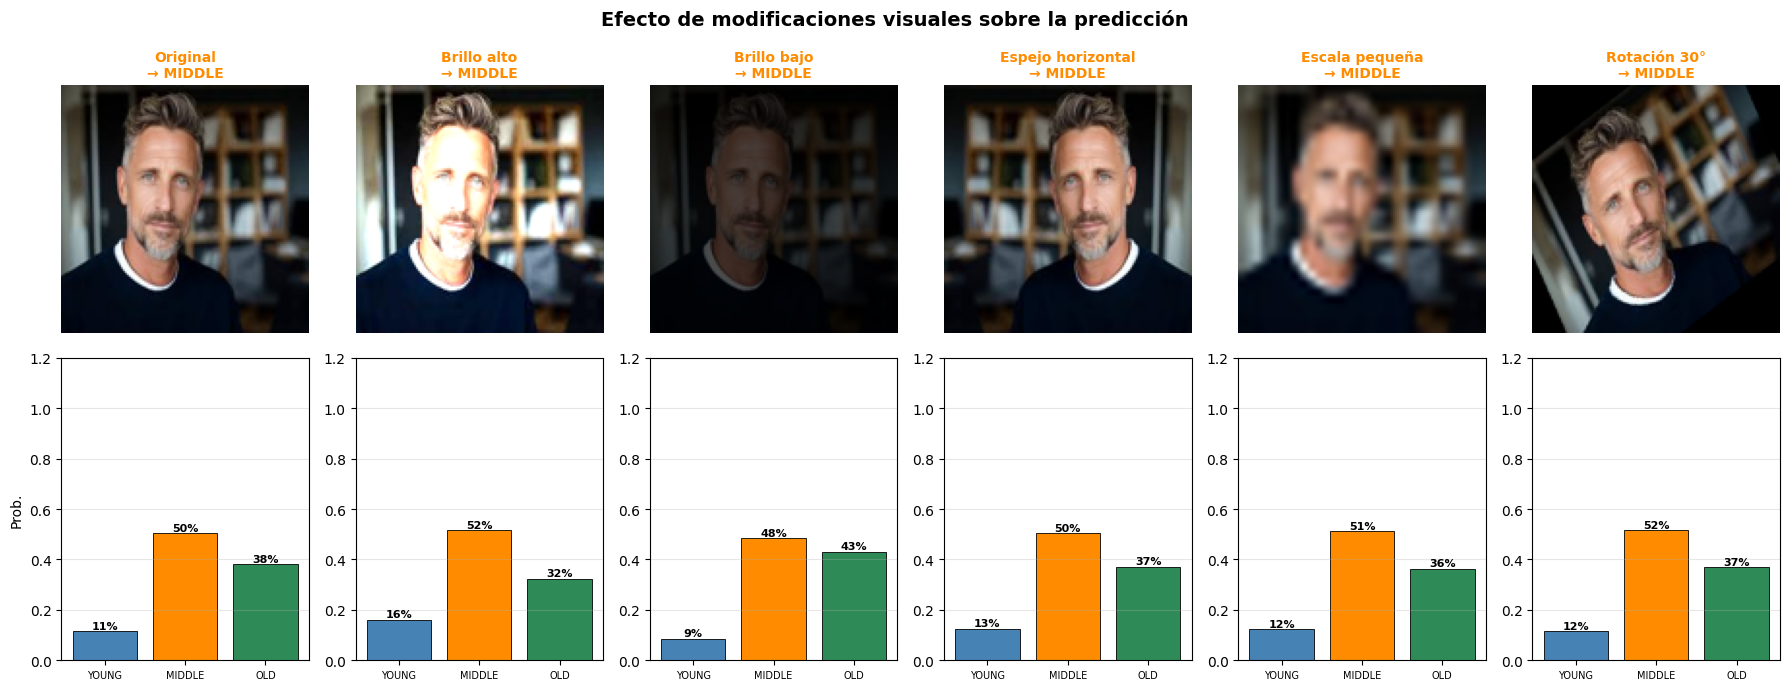

In [56]:
from PIL import ImageEnhance, ImageOps
import matplotlib.pyplot as plt
import numpy as np

def predecir(img_pil):
    """Preprocesa y predice una imagen PIL."""
    img_r     = img_pil.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img_r) / 255.0
    img_tensor = np.expand_dims(img_array, 0)
    probs     = model.predict(img_tensor, verbose=0)[0]
    pred_label = inv_label_map[np.argmax(probs)]
    return probs, pred_label

# Variaciones de la imagen original
variaciones = {
    'Original'          : img,
    'Brillo alto'       : ImageEnhance.Brightness(img).enhance(1.8),
    'Brillo bajo'       : ImageEnhance.Brightness(img).enhance(0.3),
    'Espejo horizontal' : ImageOps.mirror(img),
    'Escala pequeña'    : img.resize((32, 32)).resize((IMG_SIZE*4, IMG_SIZE*4)),
    'Rotación 30°'      : img.rotate(30),
}

# Graficar
fig, axes = plt.subplots(2, len(variaciones), figsize=(18, 7))

for i, (nombre, img_var) in enumerate(variaciones.items()):
    probs, pred_label = predecir(img_var)
    color = CLASS_COLORS.get(pred_label, 'black')

    # Imagen
    axes[0, i].imshow(img_var.resize((IMG_SIZE, IMG_SIZE)))
    axes[0, i].set_title(f"{nombre}\n→ {pred_label}", fontsize=10,
                          fontweight='bold', color=color)
    axes[0, i].axis('off')

    # Barras de probabilidad
    clases  = ['YOUNG', 'MIDDLE', 'OLD']
    colores = [CLASS_COLORS[c] for c in clases]
    bars = axes[1, i].bar(clases, probs, color=colores, edgecolor='black', linewidth=0.6)
    for bar, p in zip(bars, probs):
        axes[1, i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{p:.0%}', ha='center', fontsize=8, fontweight='bold')
    axes[1, i].set_ylim(0, 1.2)
    axes[1, i].set_ylabel('Prob.' if i == 0 else '')
    axes[1, i].grid(axis='y', alpha=0.3)
    axes[1, i].tick_params(axis='x', labelsize=7)

plt.suptitle('Efecto de modificaciones visuales sobre la predicción',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

El modelo demostró ser robusto ante todas las modificaciones visuales probadas, manteniendo la predicción MIDDLE en los 6 casos. Esto es especialmente destacable considerando que solo se entrenó por 2 épocas.

En cuanto al brillo, tanto la variación alta como la baja mantuvieron la predicción correcta, lo cual era esperable ya que el Data Augmentation incluyó variaciones de brillo durante el entrenamiento.

La variación más interesante fue el brillo bajo, donde la confusión con OLD subió de 38% a 43%. Esto se puede decir que paso porque una imagen oscura oculta detalles faciales finos como arrugas y textura de piel, que son los rasgos que el modelo usa para distinguir MIDDLE de OLD.

Finalmente, la rotación de 30° no se incluyó en el augmentation, sin embargo el modelo la manejó sin cambiar su predicción, lo que sugiere que las características aprendidas son suficientemente invariantes a pequeñas inclinaciones.